# Kryptoanalýza substituční šifry pomocí Metropolis-Hastings algoritmu

Tento notebook demonstruje použití knihovny `sifry` pro šifrování, dešifrování a automatické prolomení substituční šifry. 
Kryptoanalýza využívá **Metropolis-Hastings algoritmus** (MCMC vzorkování) nad **bigramovou maticí češtiny**.

### Jak algoritmus funguje:
1. Algoritmus analyzuje frekvenci dvojic písmen (bigramů) v referenčním textu (Krakatit).
2. Náhodně navrhuje změny v dešifrovacím klíči (prohození dvou písmen).
3. Pomocí věrohodnostní funkce (Plausibility) hodnotí, zda se dešifrovaný text začíná podobat češtině.
4. Lepší klíče přijímá vždy, horší jen s malou pravděpodobností, aby unikl z lokálních maxim.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sifry import (
    ALPHABET, normalize_text, 
    substitute_encrypt, substitute_decrypt,
    load_reference_text, build_reference_matrix, 
    transition_matrix, get_bigrams, prolom_substitute
)

# Nastavení pro čisté zobrazování grafů přímo v notebooku
%matplotlib inline
print(f"Knihovna 'sifry' úspěšně načtena. Verze abecedy má {len(ALPHABET)} znaků.")

Knihovna 'sifry' úspěšně načtena. Verze abecedy má 27 znaků.


## 1. Základní šifrování a dešifrování

Nejprve si ukážeme proces normalizace textu (odstranění diakritiky, převedení na velká písmena, náhrada mezer podtržítky `_`) a následné zašifrování pomocí pevně zvoleného klíče.

In [2]:
puvodni_text = "Příliš žluťoučký kůň úpěl ďábelské ódy."
text_normalizovany = normalize_text(puvodni_text)

# Definujeme testovací klíč (posun o 3 pozice - Caesarův posun v rámci naší abecedy)
testovaci_klic = "DEFGHIJKLMNOPQRSTUVWXYZ_ABC"

sifrovany_text = substitute_encrypt(text_normalizovany, testovaci_klic)
desifrovany_text = substitute_decrypt(sifrovany_text, testovaci_klic)

print(f"Původní text:     {puvodni_text}")
print(f"Normalizovaný:    {text_normalizovany}")
print(f"Zašifrovaný text: {sifrovany_text}")
print(f"Dešifrovaný text: {desifrovany_text}")

Původní text:     Příliš žluťoučký kůň úpěl ďábelské ódy.
Normalizovaný:    PRILIS_ZLUTOUCKY_KUN_UPEL_DABELSKE_ODY
Zašifrovaný text: SULOLVCBOXWRXFNACNXQCXSHOCGDEHOVNHCRGA
Dešifrovaný text: PRILIS_ZLUTOUCKY_KUN_UPEL_DABELSKE_ODY


## 2. Stavba jazykového modelu (Bigramová matice)

Pro prolomení neznámého textu potřebuje algoritmus vědět, jak vypadá struktura češtiny. Načteme referenční text románu *Krakatit* a vytvoříme z něj relativní bigramovou matici s Laplaceovým vyhlazováním (aby žádná pravděpodobnost nebyla přesně 0).

Log-věrohodnost ($L$) textu je pak počítána jako:
$$L = \sum_{i,j} \log(\text{reference\_matrix}[i, j]) \times \text{observed\_matrix}[i, j]$$

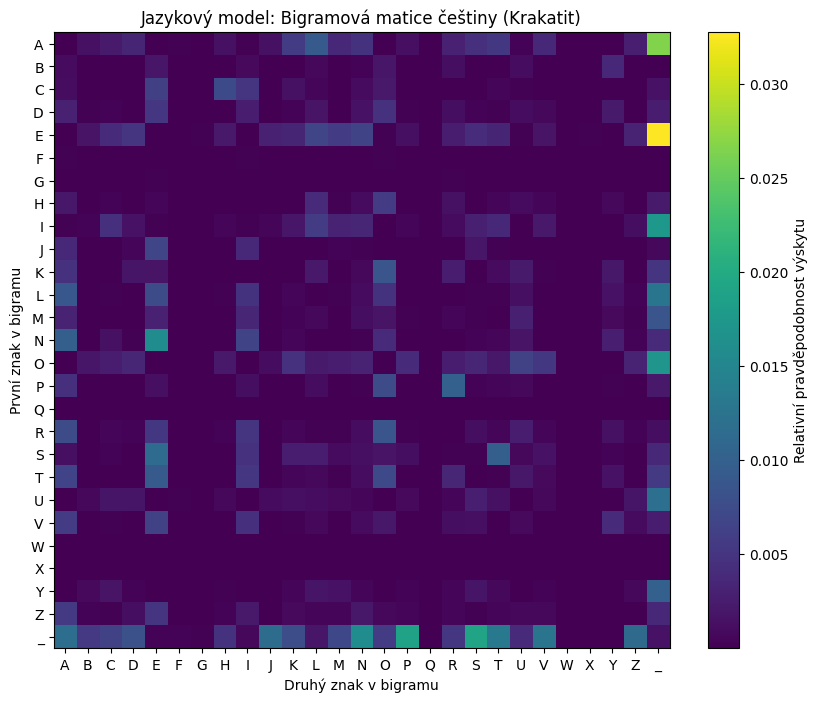

In [3]:
# Načtení dat (cesta vede o úroveň výš ze složky notebooks/)
ref_text = load_reference_text("../data/reference/krakatit.txt")
ref_matrix = build_reference_matrix(ref_text)

# Vykreslení referenční matice pomocí vestavěného matplotlib imshow
plt.figure(figsize=(10, 8))
plt.imshow(ref_matrix, cmap="viridis", aspect="equal")
plt.colorbar(label="Relativní pravděpodobnost výskytu")

# Nastavení popisků os na znaky z abecedy
plt.xticks(range(len(ALPHABET)), list(ALPHABET))
plt.yticks(range(len(ALPHABET)), list(ALPHABET))
plt.title("Jazykový model: Bigramová matice češtiny (Krakatit)")
plt.xlabel("Druhý znak v bigramu")
plt.ylabel("První znak v bigramu")
plt.show()

## 3. Kryptoanalýza s vícenásobným restartem (Multi-seed)

Vzhledem k tomu, že Metropolis-Hastings algoritmus prohledává obrovský stavový prostor, může u jednotlivých běhů (v závislosti na počátečním náhodném klíči) uvíznout v lokálním maximu a dešifrovat text jen částečně (např. zamění G za K). 

Abychom zajistili stoprocentní úspěšnost nezávisle na náhodě, implementujeme **strategii vícenásobného restartu**. Spustíme algoritmus s pěti různými seedy a na základě matematického aparátu věrohodnostní funkce automaticky vybereme ten výsledek, který dosáhl **nejvyšší log-plausibility**.

In [4]:
# Naše tajná zpráva k prolomení (zůstává stejná)
tajny_orig = normalize_text(
    "Metropolisův Hastingsův algoritmus je schopen nalézt globální maximum "
    "v obrovském prostoru možných klíčů. Tento text je dostatečně dlouhý na to, "
    "aby bigramová statistika češtiny zafungovala naprosto spolehlivě a text dešifrovala."
)

# Vygenerujeme náhodný šifrovací klíč (seed=12, aby byl ciphertext identický jako dříve)
import random
random.seed(12)
seznam_ch = list(ALPHABET)
random.shuffle(seznam_ch)
skutecny_tajny_klic = "".join(seznam_ch)
ciphertext = substitute_encrypt(tajny_orig, skutecny_tajny_klic)

# Definujeme sadu různých seedů pro kryptoanalýzu
testovane_seedy = [12, 34, 56, 78, 90]
vysledky_restartu = {}

print("Spouštím vícenásobnou kryptoanalýzu (5 běhů po 20 000 iteracích)...\n")

for s in testovane_seedy:
    # Spuštění algoritmu pro konkrétní seed
    res = prolom_substitute(
        text=ciphertext,
        reference_matrix=ref_matrix,
        iterations=20000,
        log_interval=0,  # umlčíme detailní mezivýpisy
        seed=s
    )
    
    # Spočítáme úspěšnost vůči originálu pro tento konkrétní pokus
    shodne_znaky = sum(1 for a, b in zip(tajny_orig, res.plaintext) if a == b)
    acc = (shodne_znaky / len(tajny_orig)) * 100
    
    # Uložíme výsledek
    vysledky_restartu[s] = {"vysledek": res, "presnost": acc}
    
    print(f"SEED {s:3d} -> Nejlepší log-plausibility: {res.log_plausibility:8.2f} | Přesnost: {acc:6.2f} %")
    print(f"          Ukázka textu: {res.plaintext[:75]}...\n")

# AUTOMATICKÝ VÝBĚR: Najdeme seed, který vyprodukoval NEJWYŠŠÍ (nejméně záporné) log-skóre
nejlepsi_seed = max(testovane_seedy, key=lambda s: vysledky_restartu[s]["vysledek"].log_plausibility)

# Vytáhneme finální vítězná data pro další analýzu
vysledek = vysledky_restartu[nejlepsi_seed]["vysledek"]
uspesnost = vysledky_restartu[nejlepsi_seed]["presnost"]

print(f"===============================================================")
print(f"VÍTĚZNÝ RESTART: Automaticky vybrán SEED {nejlepsi_seed} s log-skóre {vysledek.log_plausibility:.2f}")
print(f"Dosžená přesnost dešifrování: {uspesnost:.2f} %")
print(f"===============================================================")

Spouštím vícenásobnou kryptoanalýzu (5 běhů po 20 000 iteracích)...

SEED  12 -> Nejlepší log-plausibility: -1271.24 | Přesnost:  95.58 %
          Ukázka textu: METROPOLISUV_HASTINKSUV_ALKORITMUS_JE_SCHOPEN_NALEZT_KLOBALNI_MAXIMUM_V_OBR...

SEED  34 -> Nejlepší log-plausibility: -1290.39 | Přesnost:  81.86 %
          Ukázka textu: KETROPOLISUZ_HASTINCSUZ_ALCORITKUS_JE_SDHOPEN_NALEFT_CLOMALNI_KAXIKUK_Z_OMR...

SEED  56 -> Nejlepší log-plausibility: -1302.16 | Přesnost:  62.83 %
          Ukázka textu: LETRADAVISUM_HOSTINZSUM_OVZARITLUS_GE_SCHADEN_NOVEPT_ZVABOVNI_LOXILUL_M_ABR...

SEED  78 -> Nejlepší log-plausibility: -1294.11 | Přesnost:  78.76 %
          Ukázka textu: METROBOLISUZ_DASTINPSUZ_ALPORITMUS_GE_SKDOBEN_NALEFT_PLOVALNI_MAJIMUM_Z_OVR...

SEED  90 -> Nejlepší log-plausibility: -1274.29 | Přesnost:  81.42 %
          Ukázka textu: MITROPOLESUV_HASTENKSUV_ALKORETMUS_WI_SCHOPIN_NALIZT_KLOBALNE_MAFEMUM_V_OBR...

VÍTĚZNÝ RESTART: Automaticky vybrán SEED 12 s log-skóre -1271.24
D

## 4. Analýza úspěšnosti a vyhodnocení výsledků

Z výsledků jasně vyplývá korelace mezi hodnotou plausibility a reálnou úspěšností dešifrování textu. Běhy, které uvízly v lokálních maximech, vykazují výrazně nižší (více záporné) log-skóre věrohodnosti, protože výsledný text obsahuje nepřírodní bigramy způsobené špatně přiřazenými písmeny.

Níže si vizualizujeme porovnání výkonu jednotlivých seedů a následně zkontrolujeme bigramovou shodu vítězného textu s referenční češtinou.

In [ ]:
# Graf 1: Srovnání plausibility vs úspěšnosti pro jednotlivé seedy
seedy_str = [f"Seed {s}" for s in testovane_seedy]
plausibilities = [vysledky_restartu[s]["vysledek"].log_plausibility for s in testovane_seedy]
accuracies = [vysledky_restartu[s]["presnost"] for s in testovane_seedy]

# Definujeme dynamické hranice osy Y
spodni_hranice = min(plausibilities) - 30
horni_hranice = max(plausibilities) + 30

fig, ax1 = plt.subplots(figsize=(10, 4))

color = 'tab:red'
ax1.set_xlabel('Jednotlivé restarty algoritmu')
ax1.set_ylabel('Log Plausibility (vyšší = lepší)', color=color)

# OPRAVA: Sloupce nyní rostou od spodní hranice nahoru (vypočítáme jim správnou výšku)
vysky_sloupcu = [p - spodni_hranice for p in plausibilities]
bars = ax1.bar(seedy_str, vysky_sloupcu, bottom=spodni_hranice, color=color, alpha=0.6, width=0.4)

ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(spodni_hranice, horni_hranice)

# Druhá osa pro procentuální úspěšnost
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Reálná přesnost dešifrování (%)', color=color)
ax2.plot(seedy_str, accuracies, color=color, marker='o', linewidth=2, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 110)

plt.title("Srovnání log-věrohodnosti (plausibility) a skutečné přesnosti dešifrování")
fig.tight_layout()
plt.show()

# --- VIZUALIZACE MATIC (Pro vybraný nejlepší text) ---
desifrovane_bigramy = get_bigrams(vysledek.plaintext)
desifrovana_matrix = transition_matrix(desifrovane_bigramy, ALPHABET, relative=True)

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

ax[0].imshow(ref_matrix, cmap="plasma")
ax[0].set_title("Referenční čeština (Krakatit)")
ax[0].set_xticks(range(27)); ax[0].set_xticklabels(list(ALPHABET))
ax[0].set_yticks(range(27)); ax[0].set_yticklabels(list(ALPHABET))

ax[1].imshow(desifrovana_matrix, cmap="plasma")
ax[1].set_title(f"Vyluštěný text (Nejlepší restart - úspěšnost {uspesnost:.1f} %)")
ax[1].set_xticks(range(27)); ax[1].set_xticklabels(list(ALPHABET))
ax[1].set_yticks(range(27)); ax[1].set_yticklabels(list(ALPHABET))

plt.suptitle("Porovnání bigramové struktury jazyka u optimálního klíče", fontsize=16)
plt.show()

# 5. Testovaci soubory
V tejto časti sa pokúsime dešifrovať testovací súbor

In [11]:
from pathlib import Path

seed = 12


def desifruj_s_seedem(ciphertext, reference_matrix, seed, iterations=20_000):
    """Spustí prolom_substitute s daným seedom a vráti výsledok."""
    return prolom_substitute(
        text=ciphertext,
        reference_matrix=reference_matrix,
        iterations=iterations,
        log_interval=0,
        seed=seed,
    )


TESTOVACI_DIR = Path("../data/testovaci_soubory")
filepath = TESTOVACI_DIR / "text_1000_sample_10_ciphertext.txt"
ciphertext = filepath.read_text(encoding="utf-8").strip()
vysledek = desifruj_s_seedem(ciphertext, ref_matrix, seed)

#print(f"Subor: {filepath}")
#print(f"Desifrovany text: {vysledek.plaintext}")
#print()

# Desifrovat vsetky subory (trva velmi dlho)
for filepath in sorted(TESTOVACI_DIR.glob("*_ciphertext.txt")):
    ciphertext = filepath.read_text(encoding="utf-8").strip()
    vysledek = desifruj_s_seedem(ciphertext, ref_matrix, seed)


    print(f"Subor: {filepath}")
    print(f"Desifrovany text: {vysledek.plaintext}")
    print()

Subor: ../data/testovaci_soubory/text_1000_sample_10_ciphertext.txt
Desifrovany text: AKOVY_ZLY_PROGESOR_SLAVNY_UCENEC_VY_UCENCI_JSTE_VSICHNI_DIVNI_DAL_MI_UKOL_A_DIVAL_SE_NA_HODINKY_ZA_HODINU_TO_MUSELO_BYT_VYPOCITANO_A_KDYZ_UZ_MNE_ZBYVALO_JENOM_PET_MINUT_CTYRI_MINUTY_TRI_MINUTY_A_JA_NEMELA_JESTE_NIC_TU_MI_ZABOUCHALO_SRDCE_A_JA_MELA_TAKOVY_STRASNY_POCIT__ZATALA_PRSTY_DO_PROKOPOVY_PAZE_A_ZASYKLA_PAK_UZ_JSEM_SE_NA_TY_HODINY_I_TESILA_V_DEVATENACTI_MNE_ZASNOUBILI_TO_ANI_NEVIS_VID_A_PROTOZE_JSEM_UZ_VEDELA_VSECHNO_MUSEL_MNE_MUJ_ZENICH_PRISAHAT_ZE_SE_MNE_NIKDY_NEDOTKNE_ZA_DVE_LETA_PADL_V_AGRICE_VYVADELA_JSEM__Z_ROMANTIKY_NEBO_PROC__TAK_ZE_MNE_PAK_UZ_NIKDY_NENUTILI_VDAT_SE_MYSLELA_JSEM_ZE_TIM_MAM_VSECKO_ODBYTO_A_VIDIS_TEHDY_JSEM_SE_DO_TOHO_VLASTNE_JEN_NUTILA_NUTILA_JSEM_SE_VERIT_ZE_JSEM_MU_ZUSTALA_NECO_DLUZNA_A_ZE_MU_I_PO_SMRTI_MUSIM_STAT_V_SLOVE_AZ_SE_MI_NAKONEC_Z_TOHO_VSEHO_ZDALO_ZE_JSEM_HO_MILOVALA_TED_VIDIM_ZE_JSEM_TO_VSECHNO_JEN_HRALA_SAMA_PRED_SEBOU_A_ZE_JSEM_NECITILA_NIC_VIC_NIC_VIC_NEZ_

KeyboardInterrupt: 